# 01-logistic-regression-bank-marketing-campaign

**1. CARGA DEL DATASET**

In [ ]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [80]:
# CARGO LOS DATOS
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
total_data = pd.read_csv(url, sep=";")
total_data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [81]:
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [82]:
total_data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [83]:
total_data.shape

(41188, 21)

In [84]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [85]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

- El dataset contiene 41.188 filas y 21 columnas relacionadas con una campaña de marketing bancario.
- Incluye variables relacionnadas con los clientes del banco como su edad, tipo de trabajo, estado civil y nivel de educación.
- El objetivo es identificar a los clientes que tienen una mayor probabilidad de contratar un depósito a largo plazo.

In [86]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(0)

In [87]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [88]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

In [89]:
total_data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [90]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

/tmp/ipykernel_2068/1623080498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

**2. LIMPIEZA INICIAL**

In [91]:
total_data['y'].duplicated().sum()

np.int64(41186)

In [92]:
total_data[total_data['y'].duplicated() == True]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [93]:
# Esto me dice cuántos clientes aceptan y cuántos no
total_data['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

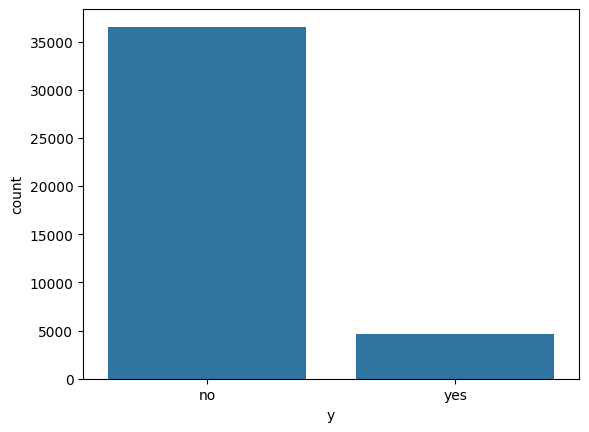

In [94]:
sns.countplot(data=total_data, x="y")
plt.show()

In [95]:
# ELIMINO LAS COLUMNAS QUE DECIDÍ ELIMINAR
total_data.drop(columns=['month','day_of_week','duration','pdays', 'nr.employed'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,age,job,marital,education,default,housing,loan,contact,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
1,57,services,married,high.school,unknown,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no


In [96]:
total_data.shape

(41188, 16)

In [97]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'campaign', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y'],
      dtype='str')

- Las variables 'month' y 'day of week' se eliminaron porque representan únicamente el momento del contacto y probablemente no influyen directamente en la decisión del cliente.
- La variable 'duration' se eliminó porque representa la duración de la llamada telefónica y solo se conoce después del contacto con el cliente, por lo que no se producirían predicciones reales.
- La variable 'pdays' se eliminó porque la mayoría de los valores corresponden a un mismo valor (999), lo que indica que el cliente no fue contactado previamente.
- La variable 'nr.employed' se eliminó para evitar redundancias con otros indicadores económicos del dataset y simplificar el modelo.

**3. ANÁLISIS DE VARIABLES**

- Variables categóricas: 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y'
- Variables numéricas: 'age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m'
- Variables eliminadas: 'month','day_of_week','duration','pdays', 'nr.employed'

**Variables categóricas**

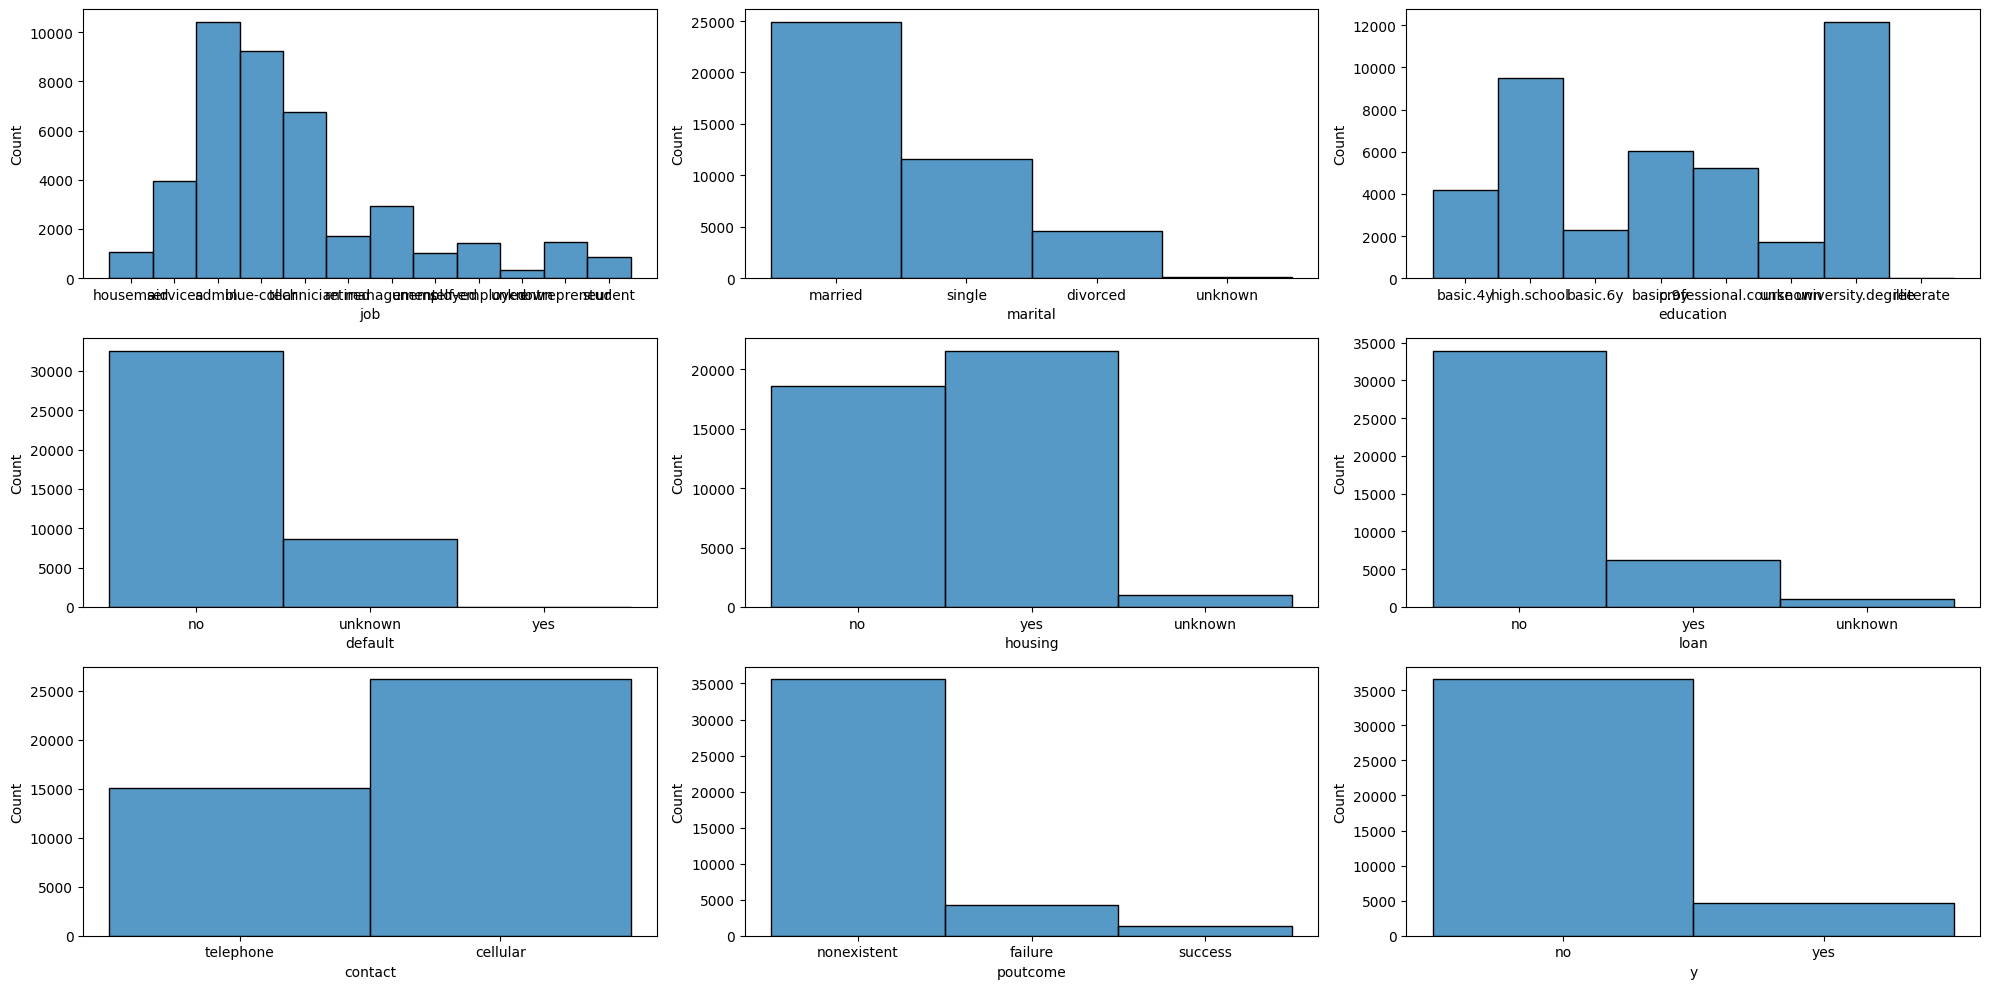

In [98]:
# HISTOGRA MÚLTIPLE
fig, axis = plt.subplots(3, 3, figsize=(20, 10))

sns.histplot(data=total_data, x='job', ax=axis[0,0])
sns.histplot(data=total_data, x='marital', ax=axis[0,1])
sns.histplot(data=total_data, x='education', ax=axis[0,2])

sns.histplot(data=total_data, x='default', ax=axis[1,0])
sns.histplot(data=total_data, x='housing', ax=axis[1,1])
sns.histplot(data=total_data, x='loan', ax=axis[1, 2])

sns.histplot(data=total_data, x='contact', ax=axis[2,0])
sns.histplot(data=total_data, x='poutcome', ax=axis[2,1])
sns.histplot(data=total_data, x='y', ax=axis[2,2])

plt.tight_layout()
plt.show()

**Variables numéricas**

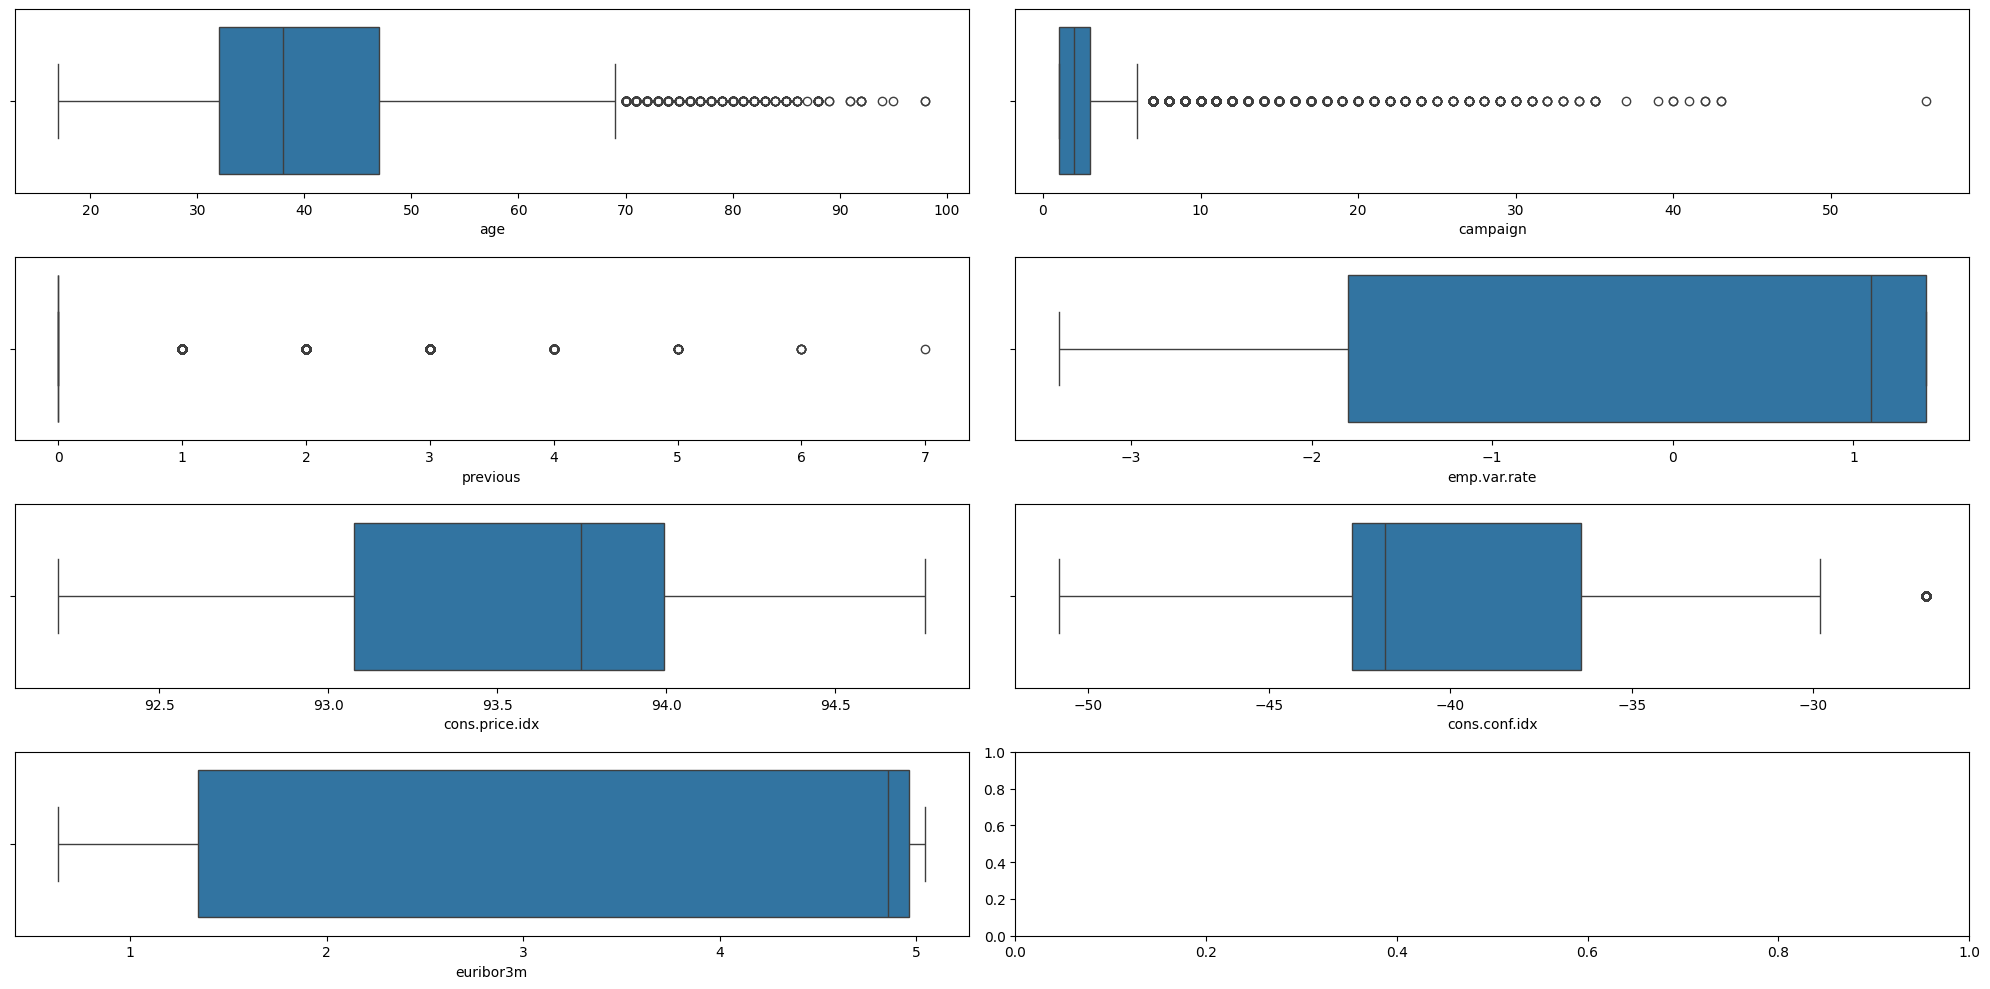

In [99]:
fig, axis = plt.subplots(4, 2, figsize = (20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["age"])
sns.boxplot(ax = axis[0, 1], x = total_data["campaign"])
sns.boxplot(ax = axis[1, 0], x = total_data["previous"])
sns.boxplot(ax = axis[1, 1], x = total_data["emp.var.rate"])
sns.boxplot(ax = axis[2, 0], x = total_data["cons.price.idx"])
sns.boxplot(ax = axis[2, 1], x = total_data["cons.conf.idx"])
sns.boxplot(ax = axis[3, 0], x = total_data["euribor3m"])

plt.tight_layout()
plt.show()

**4. RELACIONES ENTRE VARIABLES**

**Análisis numérico-numérico**

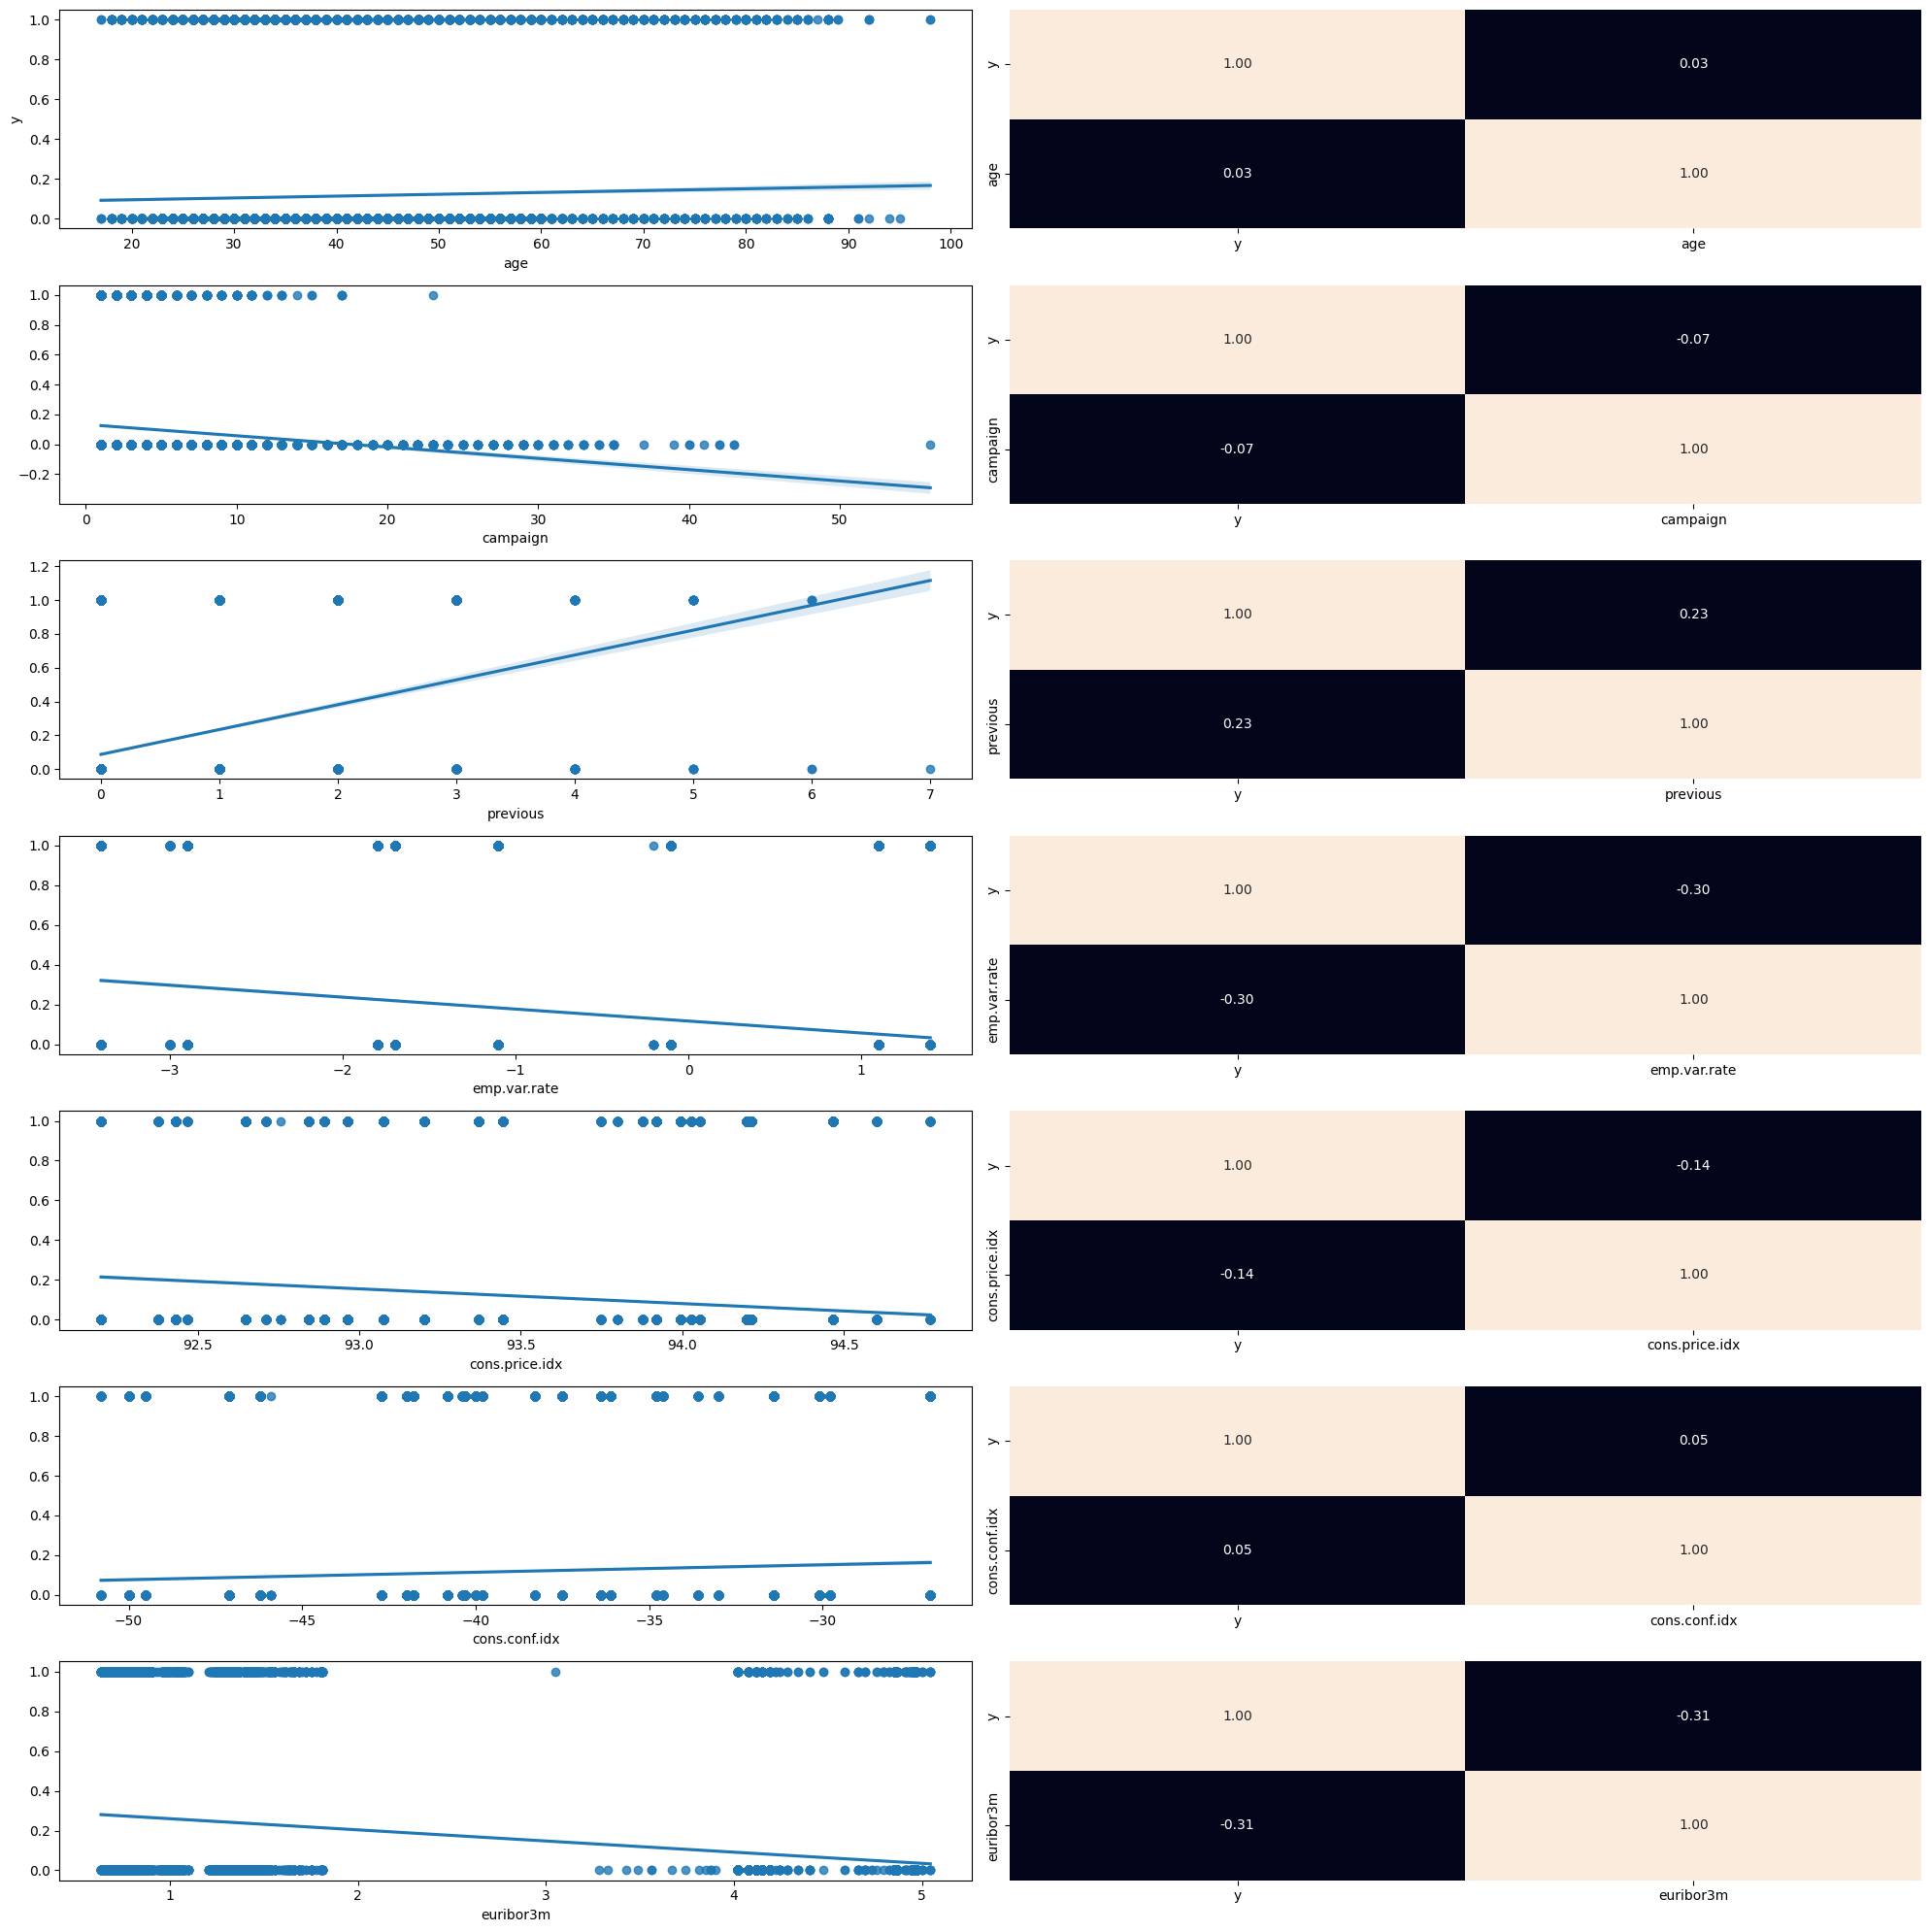

In [100]:
total_data["y"] = total_data["y"].map({"yes":1, "no":0})

fig, axis = plt.subplots(7, 2, figsize=(20, 20))

# CREO UN DIAGRAMA DE DISPERSIÓN MÚLTIPLE
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "y")
sns.heatmap(total_data[["y", "age"]].corr(),
            annot = True, fmt = ".2f", ax = axis[0, 1], cbar = False)

sns.regplot(ax = axis[1, 0], data = total_data, x = "campaign", y = "y").set(ylabel = None)
sns.heatmap(total_data[["y", "campaign"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[2, 0], data = total_data, x = "previous", y = "y").set(ylabel = None)
sns.heatmap(total_data[["y", "previous"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[2, 1], cbar=False)

sns.regplot(ax = axis[3, 0], data = total_data, x = "emp.var.rate", y = "y").set(ylabel = None)
sns.heatmap(total_data[["y", "emp.var.rate"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[3, 1], cbar=False)

sns.regplot(ax = axis[4, 0], data = total_data, x = "cons.price.idx", y = "y").set(ylabel = None)
sns.heatmap(total_data[["y", "cons.price.idx"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[4, 1], cbar=False)

sns.regplot(ax = axis[5, 0], data = total_data, x = "cons.conf.idx", y = "y").set(ylabel = None)
sns.heatmap(total_data[["y", "cons.conf.idx"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[5, 1], cbar=False)

sns.regplot(ax = axis[6, 0], data = total_data, x = "euribor3m", y = "y").set(ylabel = None)
sns.heatmap(total_data[["y", "euribor3m"]].corr(), 
            annot = True, fmt = ".2f", ax = axis[6, 1], cbar=False)

plt.tight_layout()
plt.show()

- La correlación de 'age' con 'y' es muy baja (0.03). La edad prácticamente no influye en la contratación del depósito.
- Hay una correlación negativa (-0.07) entre 'campaign' e 'y'. A mayor número de contactos en la campaña, menor es la probabilidad de que los clientes se suscriban.
- Hay una correlación positiva (0.23) entre 'previous' e 'y'. Los clientes que fueron contactados en campañas anteriores tienen más probabilidades de aceptar el depósito.
- Cuando los indicadores económicos ('emp.var.rate' y 'euribor3m') son más altos, la probabilidad de suscripción disminuye.
- Las variables 'cons.price.idx' y 'cons.conf.idx' tienen correlaciones muy bajas con 'y'.

**Análisis categórico-categórico**

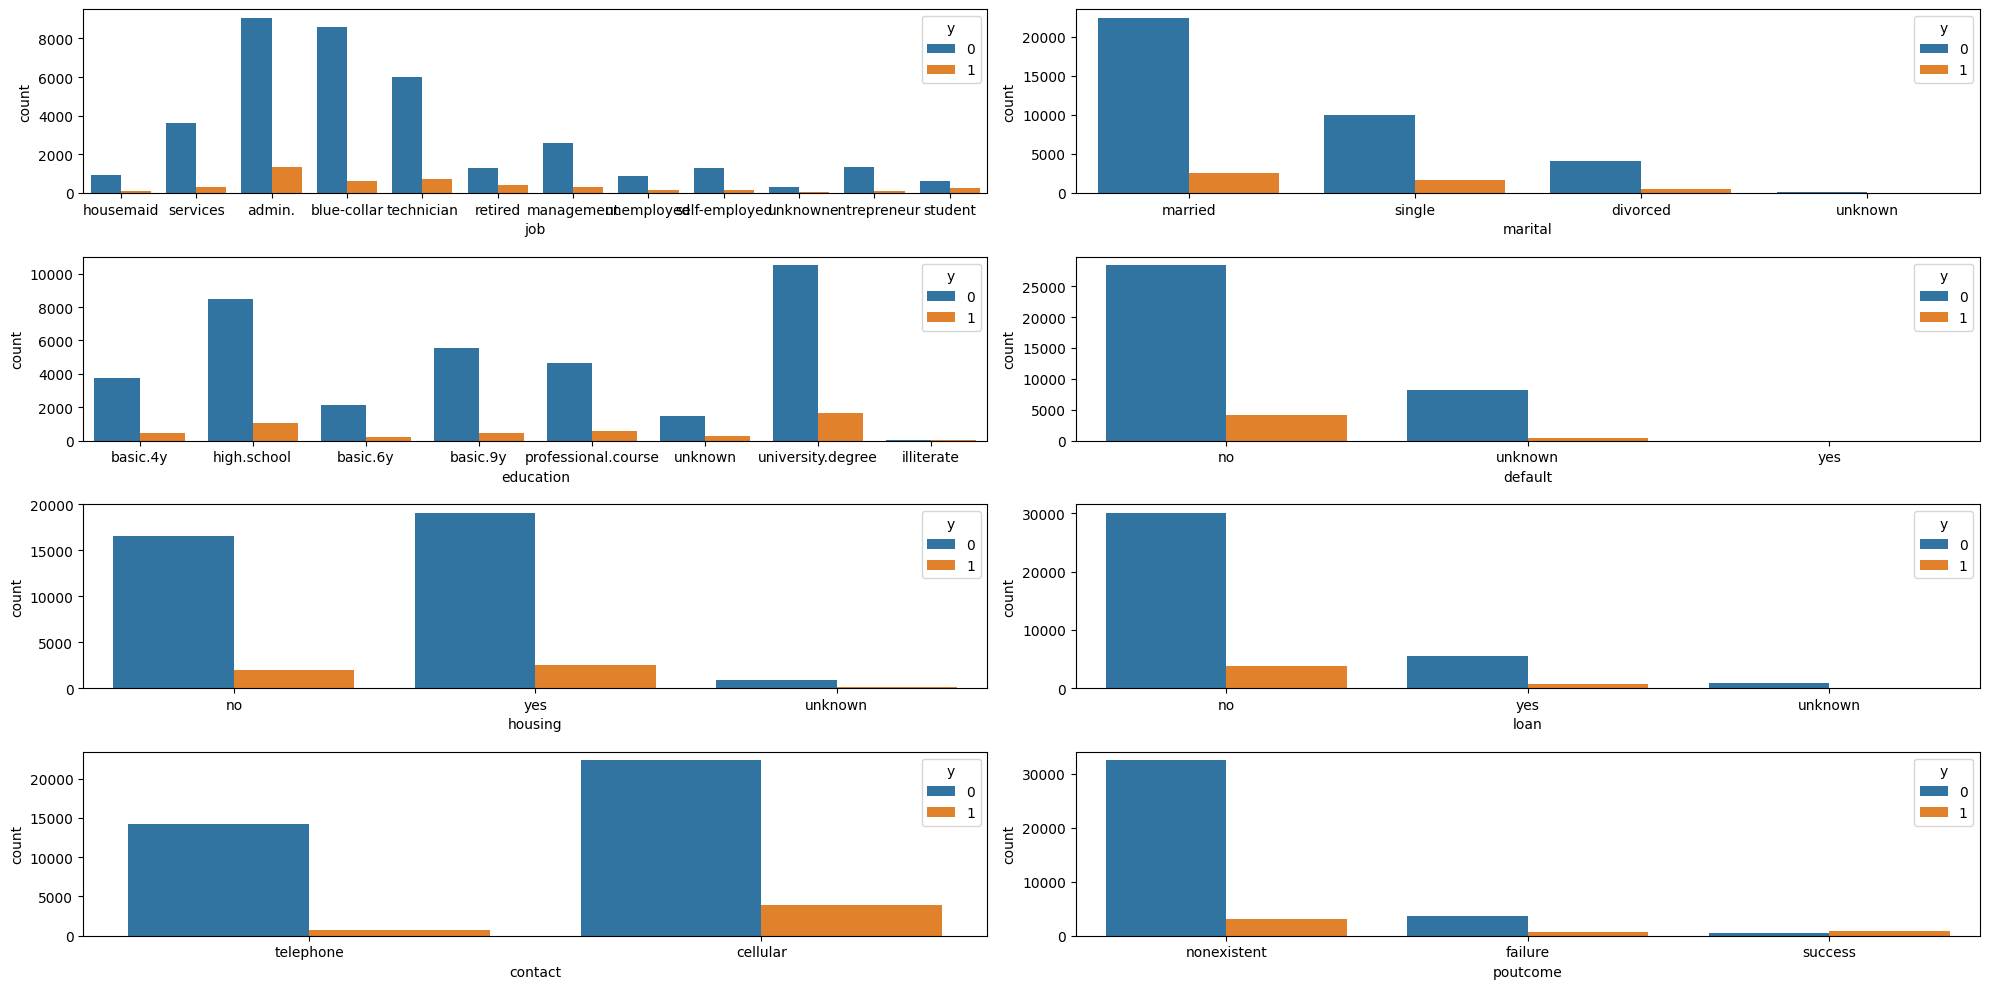

In [101]:
fig, axis = plt.subplots(4, 2, figsize=(20, 10))

# DIAGRAMA DE DISPERSIÓN MÚLTIPLE
sns.countplot(ax=axis[0,0], data=total_data, x="job", hue="y")
sns.countplot(ax=axis[0,1], data=total_data, x="marital", hue="y")
sns.countplot(ax=axis[1,0], data=total_data, x="education", hue="y")
sns.countplot(ax=axis[1,1], data=total_data, x="default", hue="y")
sns.countplot(ax=axis[2,0], data=total_data, x="housing", hue="y")
sns.countplot(ax=axis[2,1], data=total_data, x="loan", hue="y")
sns.countplot(ax=axis[3,0], data=total_data, x="contact", hue="y")
sns.countplot(ax=axis[3,1], data=total_data, x="poutcome", hue="y")

plt.tight_layout()
plt.show()

- Las variables categóricas muestran que la mayoría de los clientes tienen trabajos administrativos o técnicos, están casados y poseen educación secundaria o universitaria.
- El contacto por móvil ('cellular') es el más frecuente.
- La mayoría de los clientes no tiene préstamos personales ('loan') ni crédito en 'default'.
- Cuando la campaña anterior tuvo 'success', la probabilidad de contratar el depósito es mayor.

**Análisis numérico-categórico**

/tmp/ipykernel_2068/2657587331.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_corr.select_dtypes(include="object").columns:


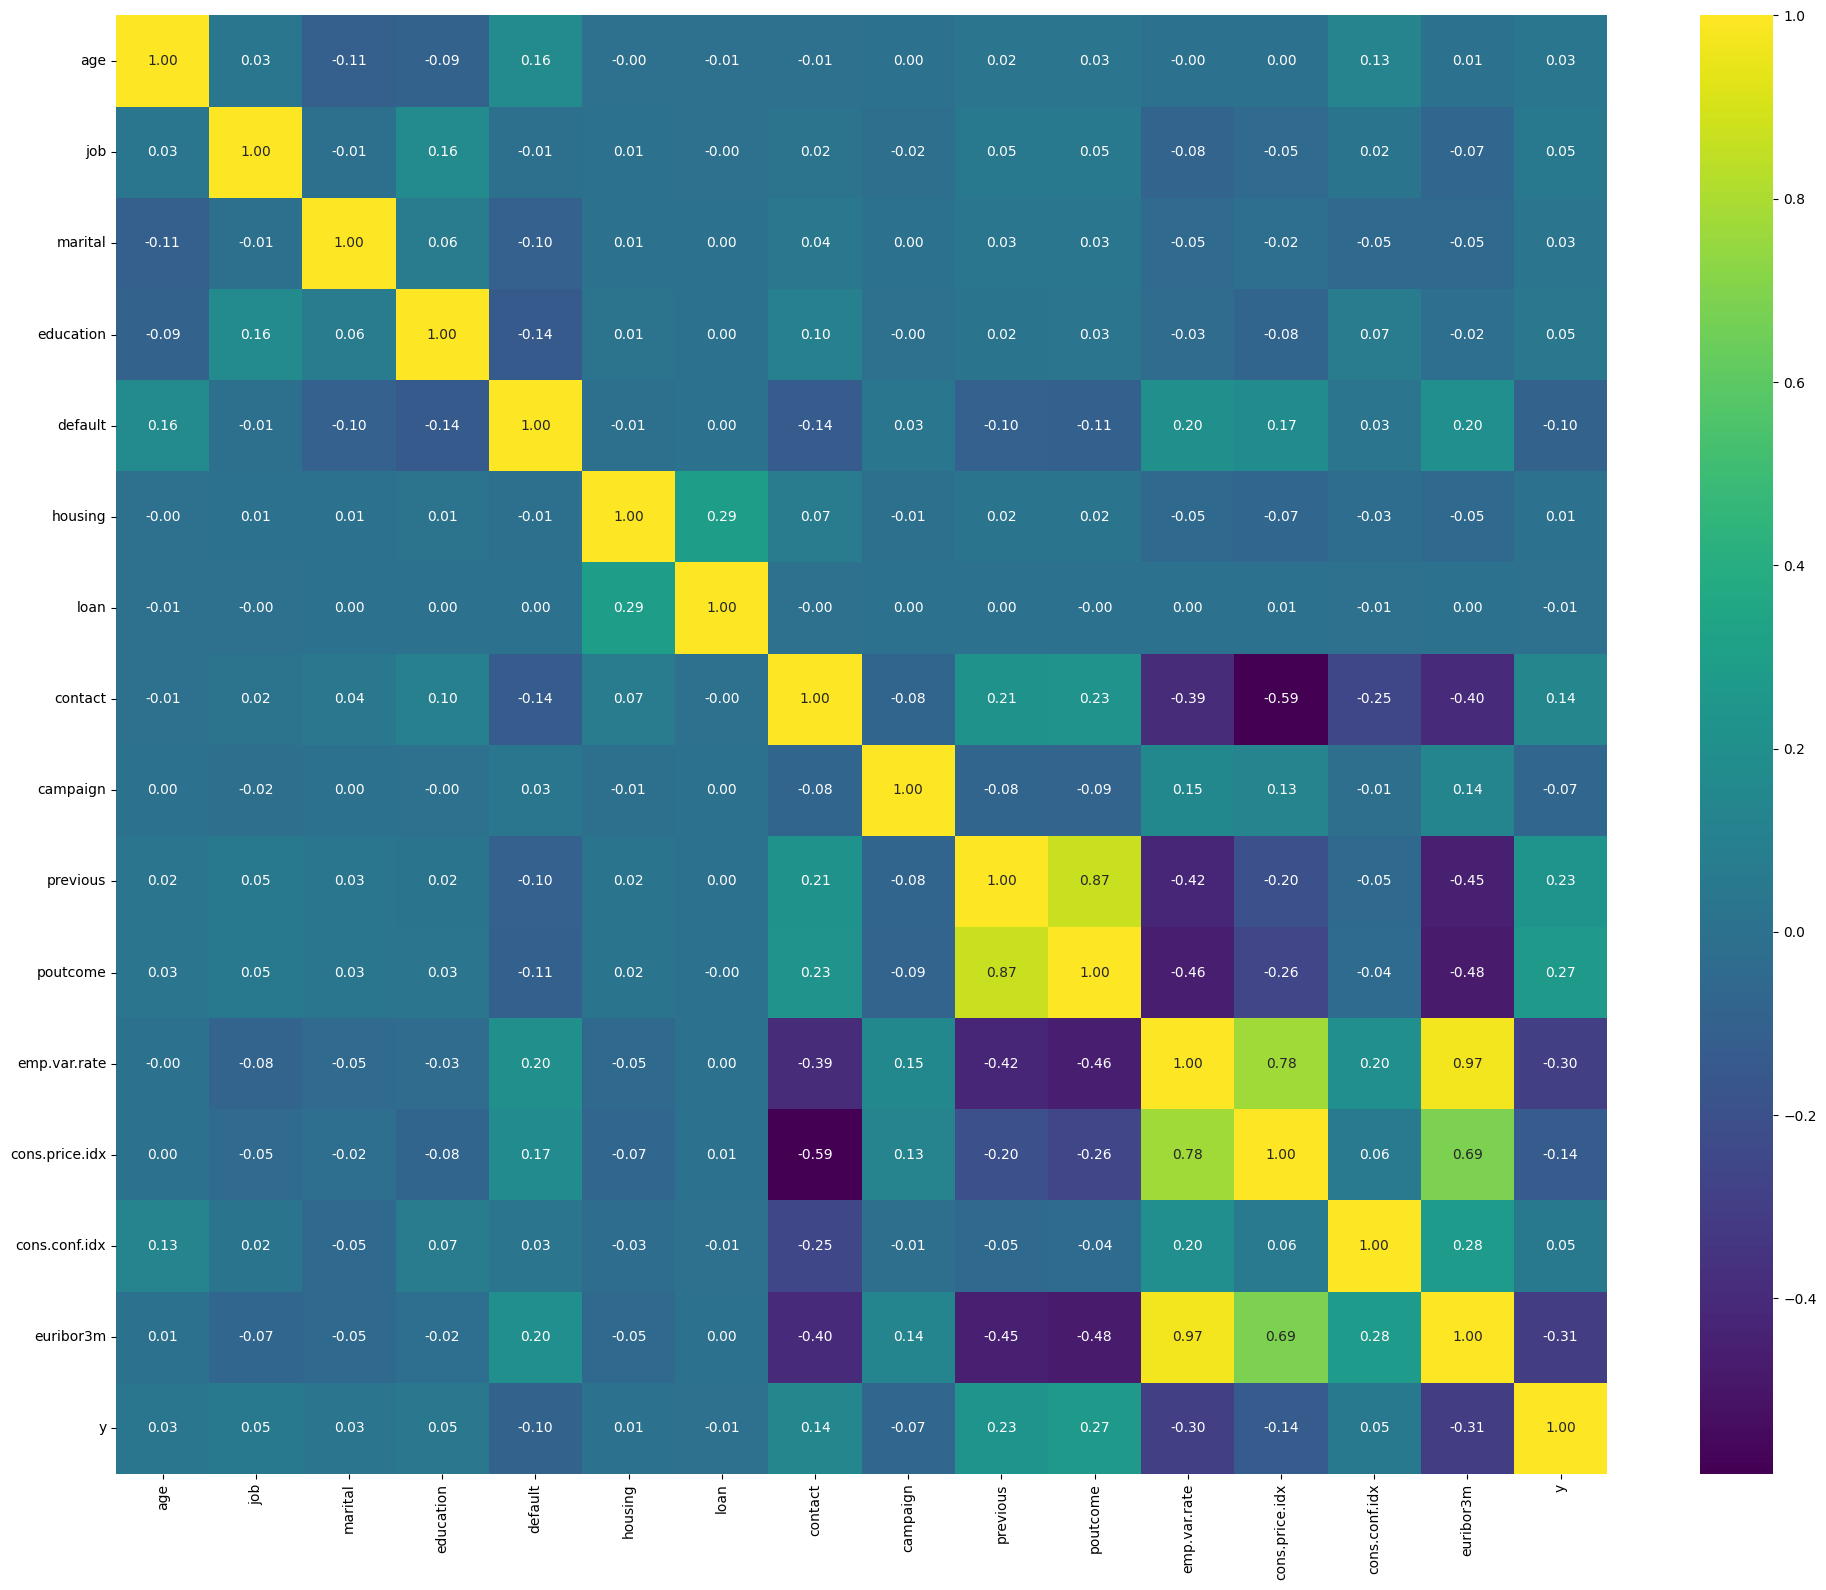

In [102]:
data_corr = total_data.copy()

for col in data_corr.select_dtypes(include="object").columns:
    data_corr[col] = pd.factorize(data_corr[col])[0]

fig, ax= plt.subplots(figsize=(20, 16))
sns.heatmap(data_corr.corr(method="pearson"),
            annot=True, fmt=".2f", cmap="viridis", ax=ax)

plt.tight_layout()
plt.show()

- La matriz de correlación muestra que hay una correlación alta entre varios indicadores macroeconómicos como 'emp.var.rate', 'cons.price.idx' y 'euribor3m', lo que sugiere la posible presencia de multicolinealidad entre esas variables.
- Sin embargo, la variable 'y' presenta correlaciones bajas con la mayoría de las demás variables, lo que sugiere que la predicción va a depender de la combinación de varias características más que de una sola variable.

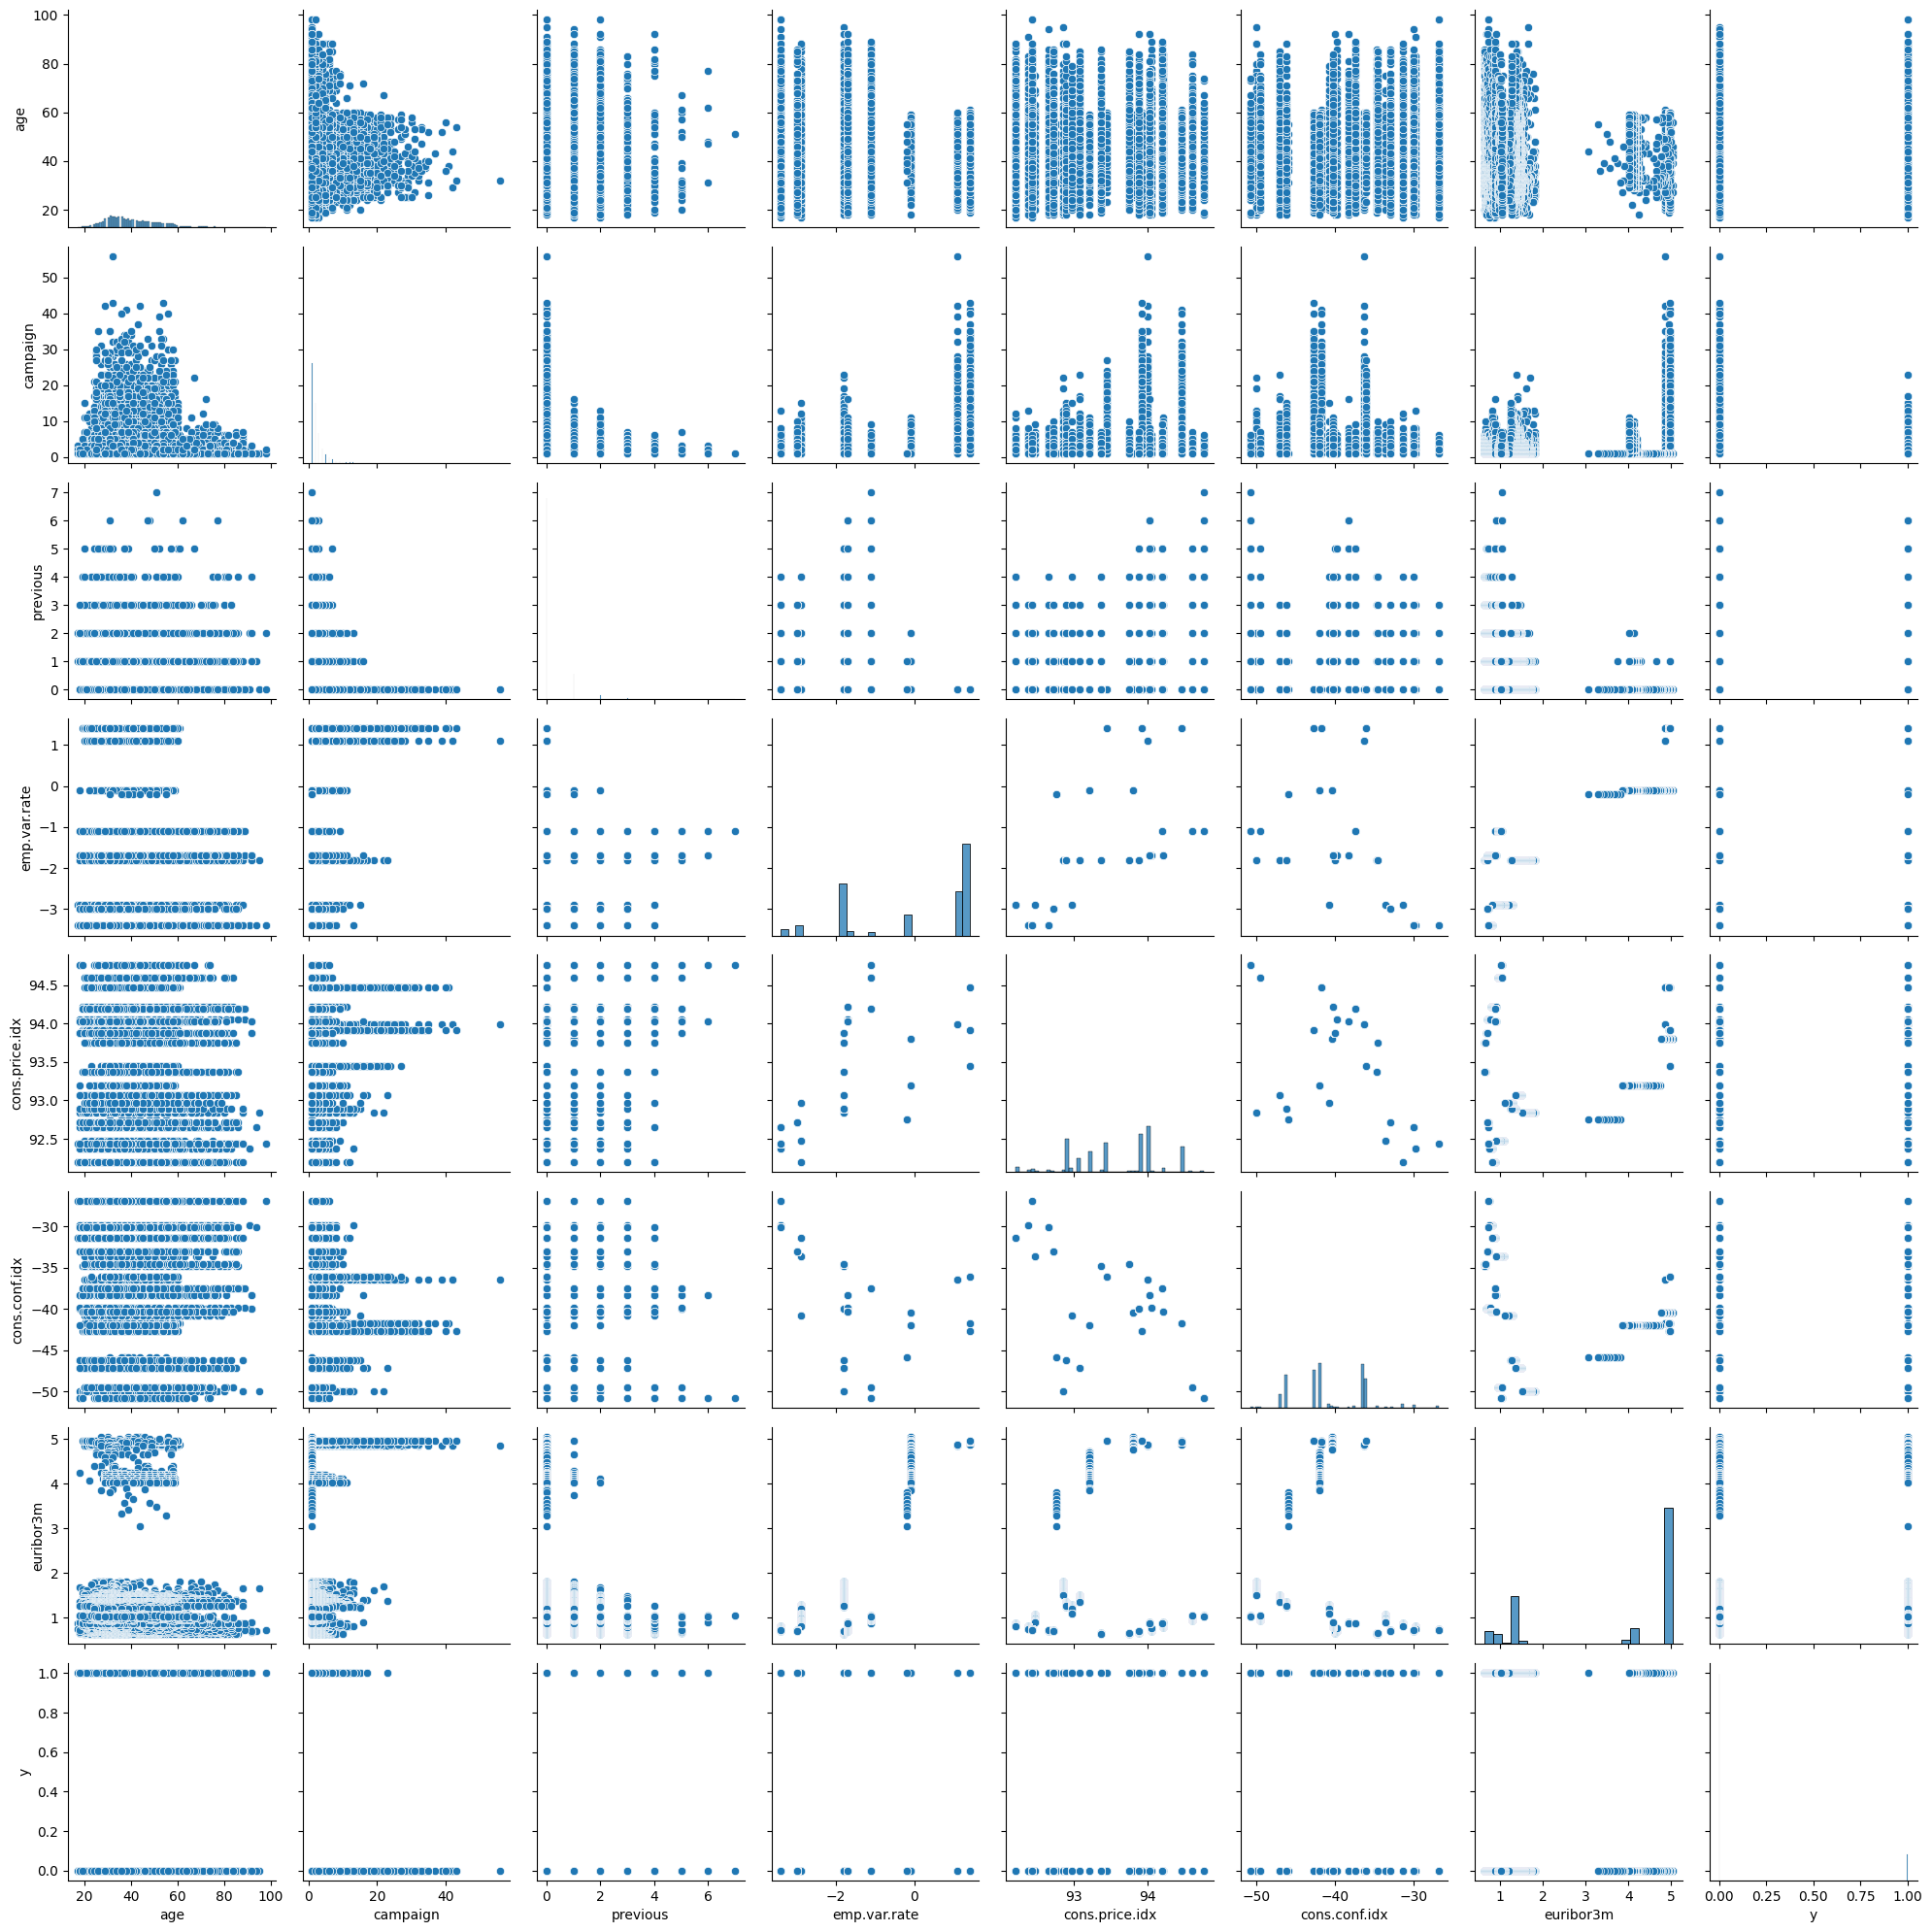

In [103]:
total_data["y"] = total_data["y"].fillna(0)

sns.pairplot(data=total_data)
plt.tight_layout()
plt.show()

**5. INGENIERÍA DE CARACTERÍSTICAS**

In [104]:
total_data.describe()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,0.172963,0.081886,93.575664,-40.502600,3.621291,0.112654
std,10.42125,2.770014,0.494901,1.570960,0.578840,4.628198,1.734447,0.316173
min,17.00000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,0.000000
25%,32.00000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,0.000000
50%,38.00000,2.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,0.000000
75%,47.00000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,0.000000
max,98.00000,56.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,1.000000


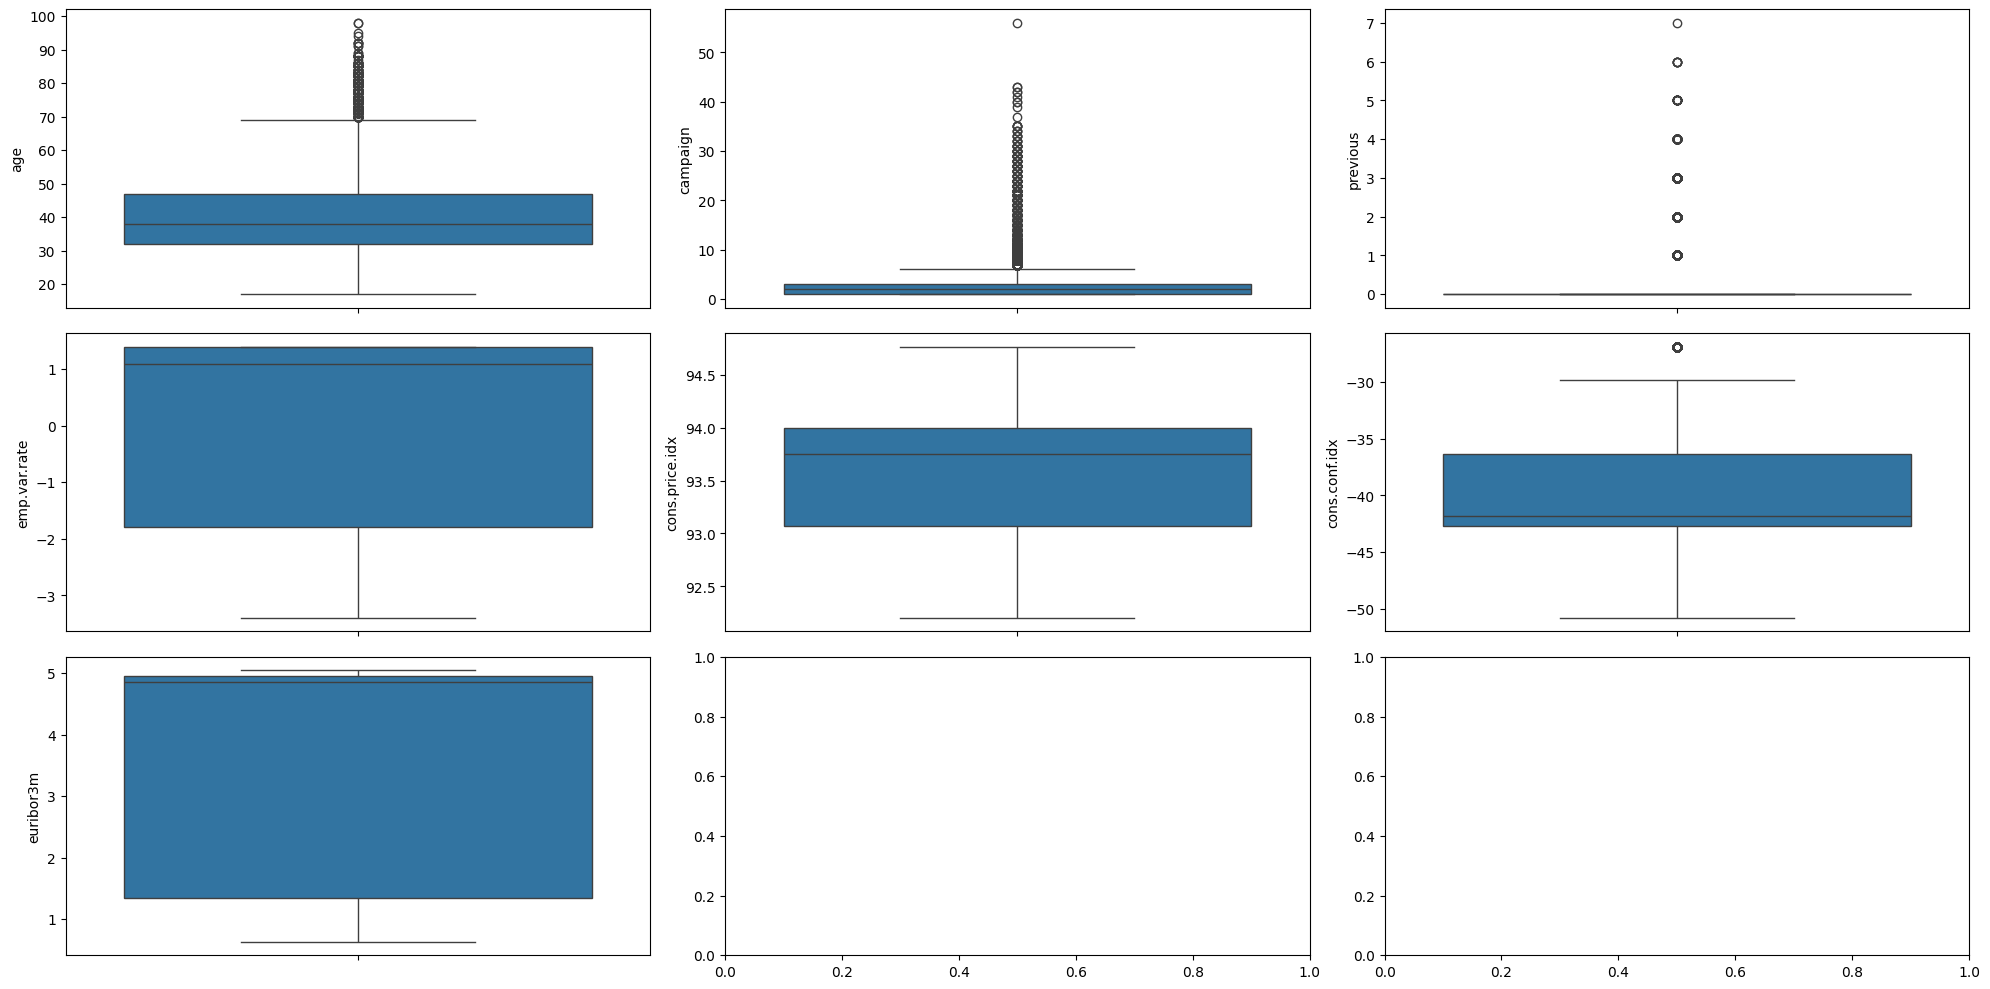

In [105]:
# Boxplots de variables numéricas: 'age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m'
fig, axs = plt.subplots(3, 3, figsize=(20, 10))

sns.boxplot(ax=axs[0, 0], data=total_data, y="age")
sns.boxplot(ax=axs[0, 1], data=total_data, y="campaign")
sns.boxplot(ax=axs[0, 2], data=total_data, y="previous")
sns.boxplot(ax=axs[1, 0], data=total_data, y="emp.var.rate")
sns.boxplot(ax=axs[1, 1], data=total_data, y="cons.price.idx")
sns.boxplot(ax=axs[1, 2], data=total_data, y="cons.conf.idx")
sns.boxplot(ax=axs[2, 0], data=total_data, y="euribor3m")

plt.tight_layout()
plt.show()

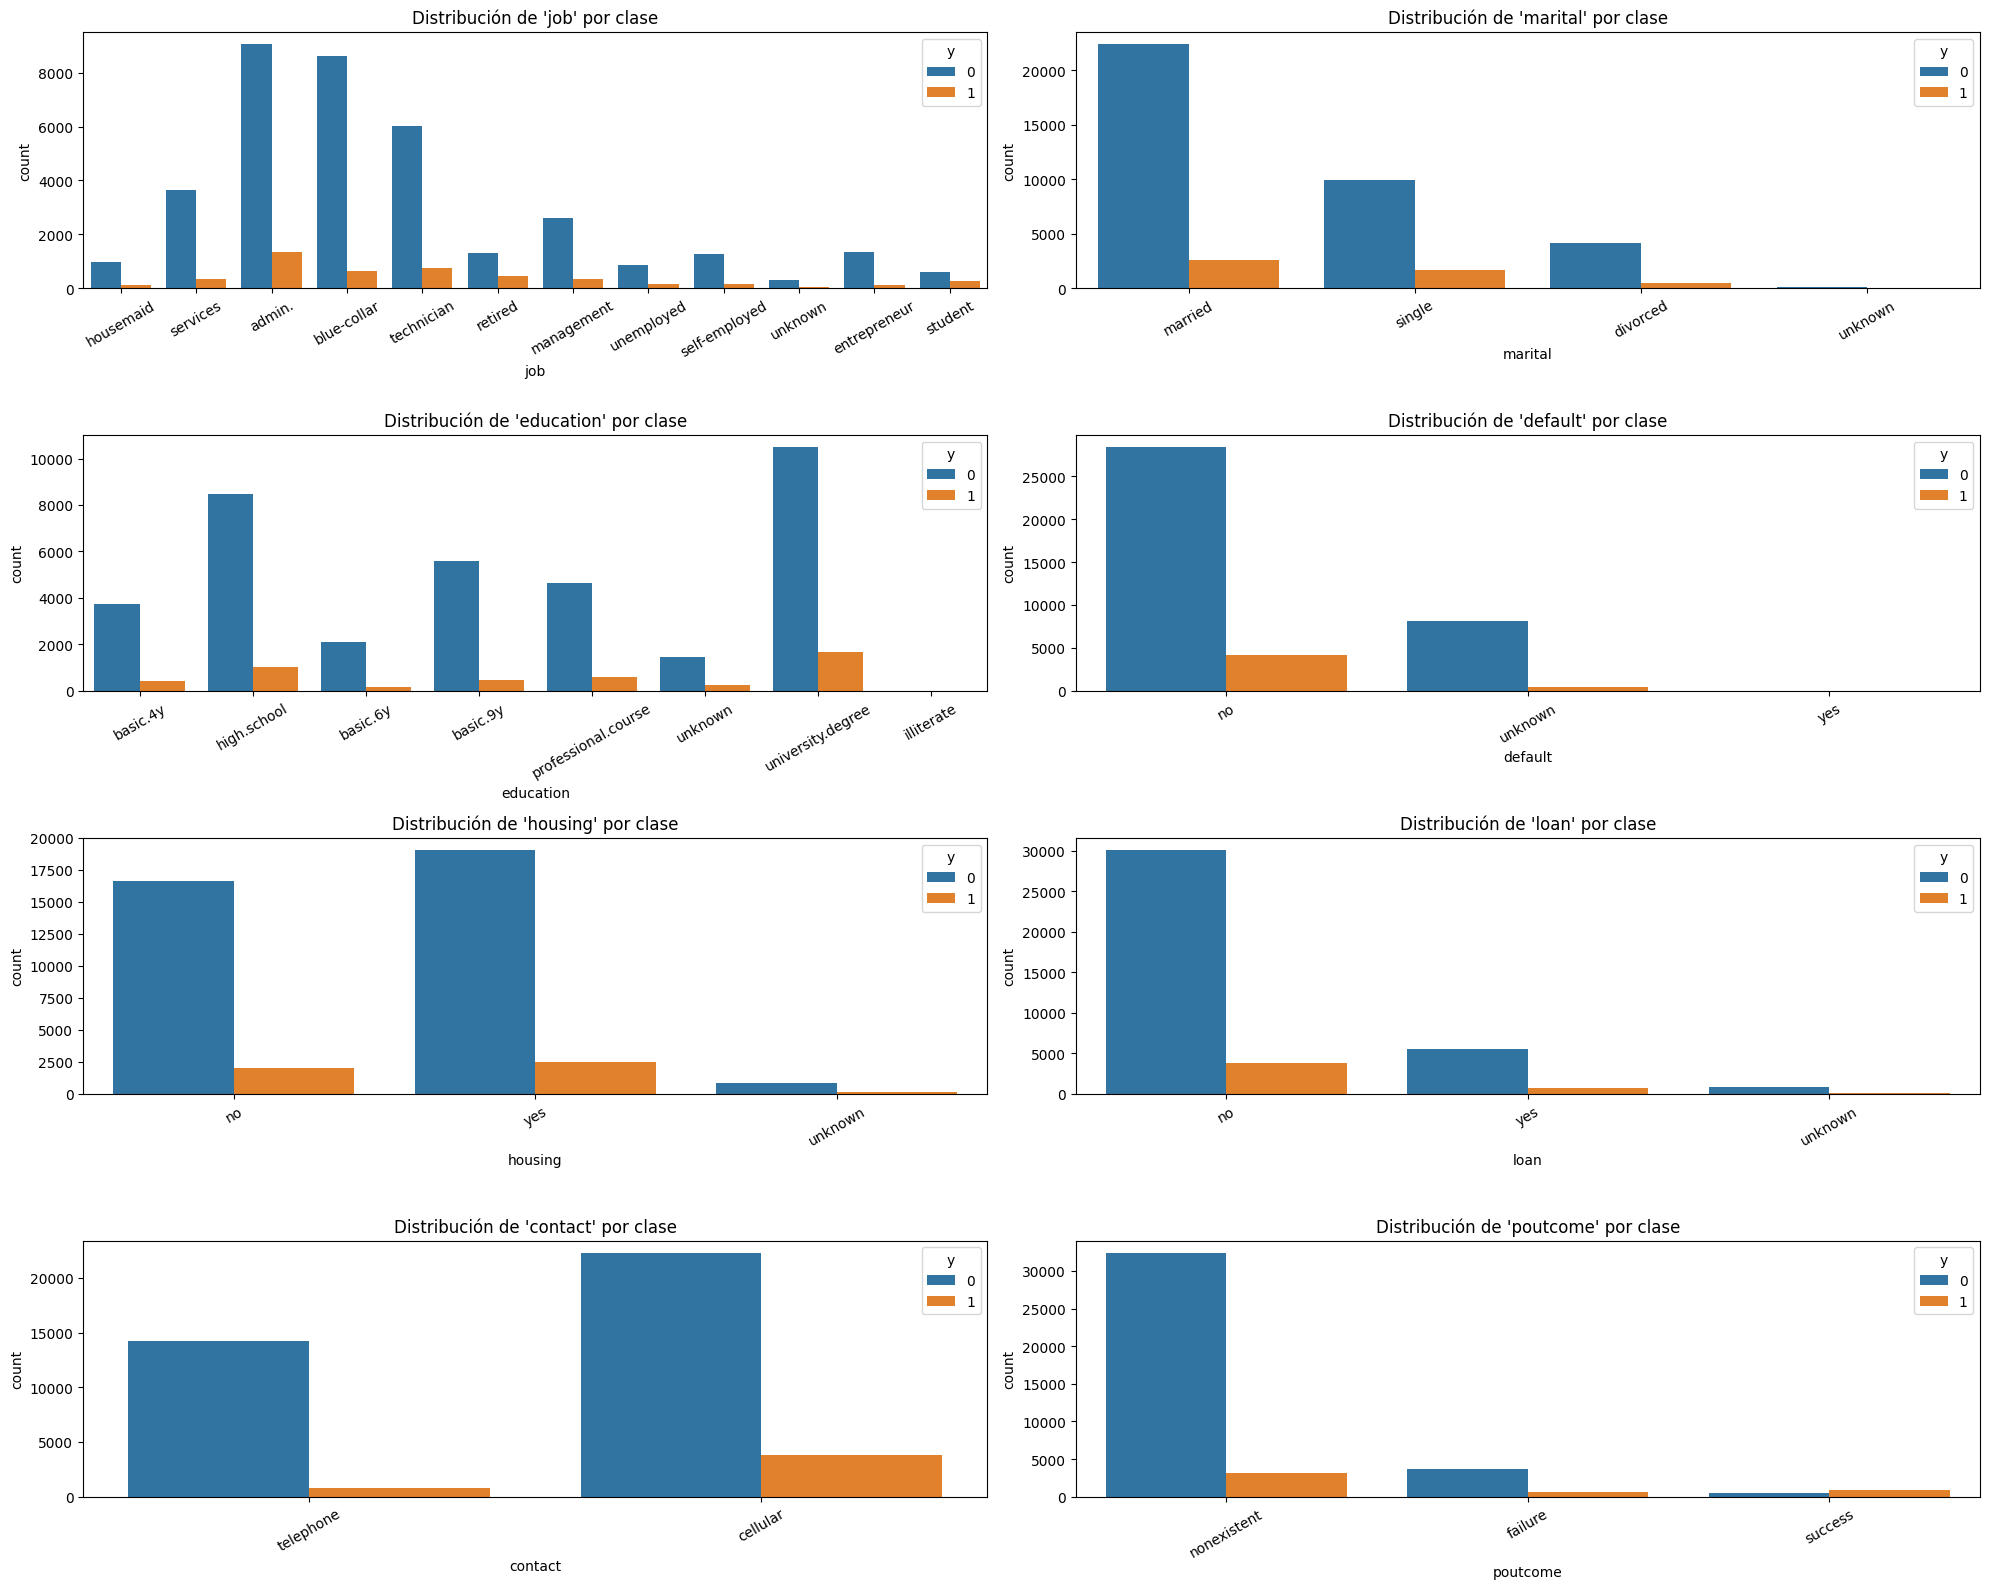

In [106]:
# Countplots de variables categóricas
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
fig, axs = plt.subplots(4, 2, figsize=(20, 16))
axs = axs.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(ax=axs[i], data=total_data, x=col, hue="y")
    axs[i].set_title(f"Distribución de '{col}' por clase")
    axs[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [107]:
# FUNCIÓN REUTILIZABLE PARA DETECTAR OUTLIERS
def detect_outliers_iqr(data, column_name):
    stats = data[column_name].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    outliers = data[(data[column_name] < lower_limit) | (data[column_name] > upper_limit)]

    print(f"\n{column_name.upper()}")
    print(f"  IQR: {iqr:.2f} | Límite inferior: {lower_limit:.2f} | Límite superior: {upper_limit:.2f}")
    print(f"  Outliers: {len(outliers)}")
    
    return outliers, lower_limit, upper_limit

numeric_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']

for col in numeric_cols:
    detect_outliers_iqr(total_data, col)


AGE
  IQR: 15.00 | Límite inferior: 9.50 | Límite superior: 69.50
  Outliers: 469

CAMPAIGN
  IQR: 2.00 | Límite inferior: -2.00 | Límite superior: 6.00
  Outliers: 2406

PREVIOUS
  IQR: 0.00 | Límite inferior: 0.00 | Límite superior: 0.00
  Outliers: 5625

EMP.VAR.RATE
  IQR: 3.20 | Límite inferior: -6.60 | Límite superior: 6.20
  Outliers: 0

CONS.PRICE.IDX
  IQR: 0.92 | Límite inferior: 91.70 | Límite superior: 95.37
  Outliers: 0

CONS.CONF.IDX
  IQR: 6.30 | Límite inferior: -52.15 | Límite superior: -26.95
  Outliers: 447

EURIBOR3M
  IQR: 3.62 | Límite inferior: -4.08 | Límite superior: 10.39
  Outliers: 0


- Aunque se detectaron valores extremos, se decidió no eliminarlos porque pueden representar comportamientos reales relevantes para la predicción.

**Análisis de los valores faltantes**

In [108]:
total_data.isnull().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
campaign          0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
y                 0
dtype: int64

**6. TRAIN / TEST SPLIT**

In [ ]:
# SEPARO X E Y
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
numeric_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']

mi_x = total_data[categorical_cols + numeric_cols]
mi_y = total_data["y"]

In [ ]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(mi_x, mi_y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

In [ ]:
# ONE HOT ENCODING
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded  = encoder.transform(X_test[categorical_cols])

In [112]:
# LOGISTIC REGRESSION
logmodel = LogisticRegression(max_iter=1000)

In [113]:
# ENTRENO EL MODELO
logmodel.fit(X_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [114]:
# PREDICCIONES
y_pred = logmodel.predict(X_test)

In [115]:
# ACCURACY
accuracy_score(y_test, y_pred)

0.8971837824714737

In [116]:
# MATRIZ DE CONFUSIÓN
confusion_matrix(y_test, y_pred)

array([[7226,   77],
       [ 770,  165]])

In [117]:
# REPORTE COMPLETO
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7303
           1       0.68      0.18      0.28       935

    accuracy                           0.90      8238
   macro avg       0.79      0.58      0.61      8238
weighted avg       0.88      0.90      0.87      8238



**7. OPTIMIZACIÓN DEL MODELO**

In [ ]:
# FEATURE SCALING
scaler = StandardScaler()
X_train_numeric = scaler.fit_transform(X_train[numeric_cols])
X_test_numeric  = scaler.transform(X_test[numeric_cols])

In [119]:
# REGULARIZACIÓN
logmodel = LogisticRegression(C=0.5)

In [120]:
# REPORTE COMPLETO
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7303
           1       0.68      0.18      0.28       935

    accuracy                           0.90      8238
   macro avg       0.79      0.58      0.61      8238
weighted avg       0.88      0.90      0.87      8238



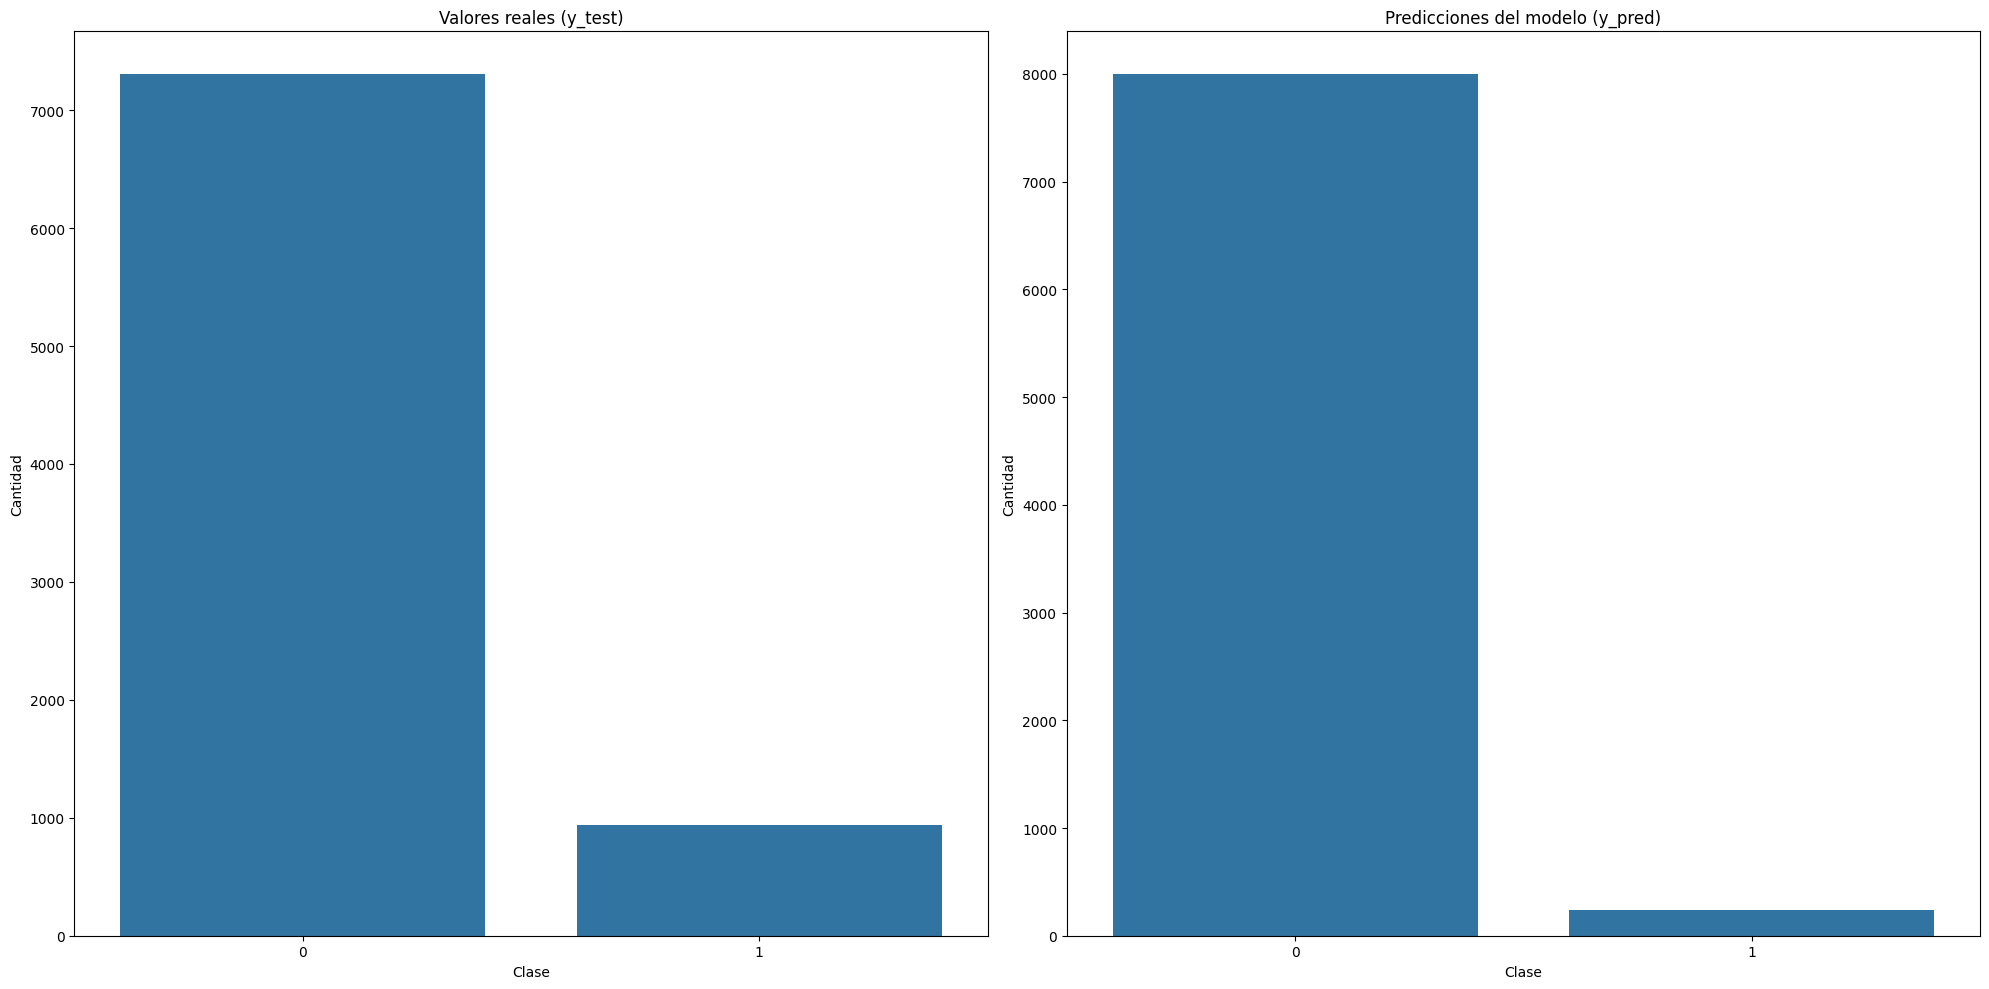

In [121]:
# GRÁFICO VALORES REALES VS VALORES PREDICHOS
fig, axis = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(x=y_test, ax=axis[0])
axis[0].set_title("Valores reales (y_test)")
axis[0].set_xlabel("Clase")
axis[0].set_ylabel("Cantidad")

sns.countplot(x=y_pred, ax=axis[1])
axis[1].set_title("Predicciones del modelo (y_pred)")
axis[1].set_xlabel("Clase")
axis[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

**8. CONCLUSIONES**

- El dataset inicial contenía 41.188 filas y 21 columnas relacionadas con una campaña de marketing bancario.
- Incluye variables relacionnadas con los clientes del banco como su edad, tipo de trabajo, estado civil y nivel de educación.
- El objetivo es identificar a los clientes que tienen una mayor probabilidad de contratar un depósito a largo plazo.

**Variables eliminadas**
- Las variables 'month' y 'day of week' se eliminaron porque representan únicamente el momento del contacto y probablemente no influyen directamente en la decisión del cliente.
- La variable 'duration' se eliminó porque representa la duración de la llamada telefónica y solo se conoce después del contacto con el cliente, así que no se producirían predicciones reales.
- La variable 'pdays' se eliminó porque la mayoría de los valores corresponden a un mismo valor (999), lo que indica que el cliente no fue contactado previamente.
- La variable 'nr.employed' se eliminó para evitar redundancias con otros indicadores económicos del dataset y simplificar el modelo.
- Aunque se detectaron valores extremos, se decidió no eliminarlos porque pueden representar comportamientos reales relevantes para la predicción.

**Análisis numerérico-numérico**
- La correlación de 'age' con 'y' es muy baja (0.03). La edad prácticamente no influye en la contratación del depósito.
- Hay una correlación negativa (-0.07) entre 'campaign' e 'y'. A mayor número de contactos en la campaña, menor es la probabilidad de que los clientes se suscriban.
- Hay una correlación positiva (0.23) entre 'previous' e 'y'. Los clientes que fueron contactados en campañas anteriores tienen más probabilidades de aceptar el depósito.
- Cuando los indicadores económicos ('emp.var.rate' y 'euribor3m') son más altos, la probabilidad de suscripción disminuye.
- Las variables 'cons.price.idx' y 'cons.conf.idx' tienen correlaciones muy bajas con 'y'.

**Análisis categórico-categórico**
- Las variables categóricas muestran que la mayoría de los clientes tienen trabajos administrativos o técnicos, están casados y poseen educación secundaria o universitaria.
- El contacto por móvil ('cellular') es el más frecuente.
- La mayoría de los clientes no tiene préstamos personales ('loan') ni crédito en 'default'.
- Cuando la campaña anterior tuvo 'success', la probabilidad de contratar el depósito es mayor.

**Matriz de correlación**
- La matriz de correlación muestra que hay una correlación alta entre varios indicadores macroeconómicos como 'emp.var.rate', 'cons.price.idx' y 'euribor3m', lo que sugiere la posible presencia de multicolinealidad entre esas variables.
- Sin embargo, la variable 'y' presenta correlaciones bajas con la mayoría de las demás variables, lo que sugiere que la predicción va a depender de la combinación de varias características más que de una sola variable.

**Conclusiones del proyecto**
- El modelo de regresión logística fue capaz de predecir si un cliente contrataría un depósito a largo plazo con una precisión aproximada de 90% (accuracy = 0.897). 
- Algunas variables como la duración de la llamada ('duration') y el número de contactos durante la campaña ('campaign') parecen tener mayor influencia en la predicción.
- El modelo identifica correctamente la mayoría de los casos negativos, pero tiene más dificultad detectando clientes que sí contratarían el depósito.